In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import plotly.express as px
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [4]:
DATA_PATH = r'Instagram_Analytics.csv'
OUT_DIR = './Graph_plot/'

In [5]:
insta_df = pd.read_csv(DATA_PATH)

In [6]:
insta_df

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,IG0000001,25:23.0,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,IG0000002,25:23.0,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,IG0000003,25:23.0,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,IG0000004,25:23.0,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,IG0000005,25:23.0,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,IG0029995,25:23.0,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,IG0029996,25:23.0,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,IG0029997,25:23.0,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,IG0029998,25:23.0,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


In [7]:
insta_df.describe()

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate
count,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,2.999900e+04,29999.000000,29999.000000,29999.000000,29999.000000
mean,99912.661789,5017.781426,2502.912564,7490.124637,9.965616e+05,1.246669e+06,1103.110904,14.887430,502.152805,14.419276
std,57905.967401,2888.404881,1448.320395,4352.546949,5.777906e+05,5.970924e+05,635.991308,9.005811,290.364038,29.660210
min,7.000000,0.000000,0.000000,0.000000,1.650000e+02,5.107000e+03,0.000000,0.000000,0.000000,0.120000
25%,49755.000000,2530.500000,1246.000000,3690.500000,4.936810e+05,7.469585e+05,555.000000,7.000000,251.000000,5.180000
50%,99580.000000,5042.000000,2498.000000,7483.000000,9.921810e+05,1.241026e+06,1100.000000,15.000000,501.000000,9.190000
75%,150225.000000,7518.000000,3768.000000,11294.000000,1.494798e+06,1.749264e+06,1656.000000,23.000000,755.000000,15.670000
max,200000.000000,10000.000000,5000.000000,15000.000000,1.999865e+06,2.497940e+06,2200.000000,30.000000,1000.000000,3259.820000


In [8]:
insta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
dtypes: float64(1), int64(9), object(5)
memory usage: 3.4+ MB


In [9]:
insta_df = insta_df.drop(columns=['post_id','upload_date'])

In [10]:
insta_df

,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category
0,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology
1,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness
2,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty
3,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music
4,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,Video,46046,8354,3847,11095,597992,820688,1254,18,124,Reels Feed,8.45,Travel
29995,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,Hashtags,3.78,Beauty
29996,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,Explore,2.90,Photography
29997,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,Explore,8.64,Technology


In [11]:
insta_df.isnull().sum().sort_values(ascending=False)

media_type          0
likes               0
comments            0
shares              0
saves               0
reach               0
impressions         0
caption_length      0
hashtags_count      0
followers_gained    0
traffic_source      0
engagement_rate     0
content_category    0
dtype: int64

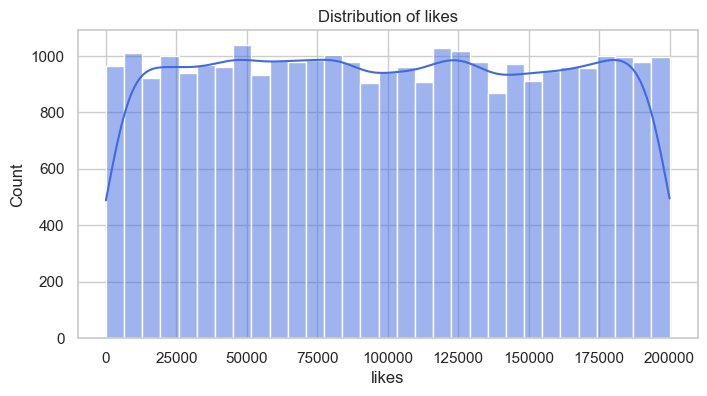

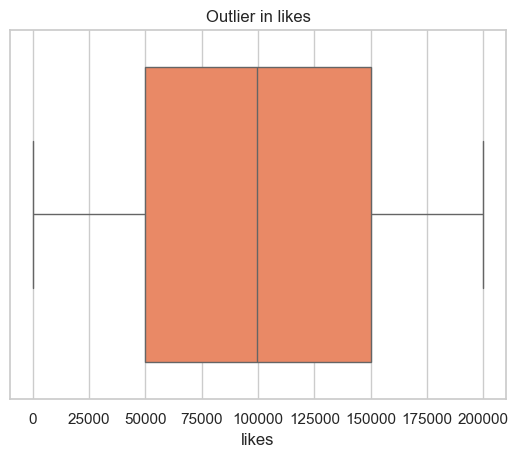

<Figure size 640x480 with 0 Axes>

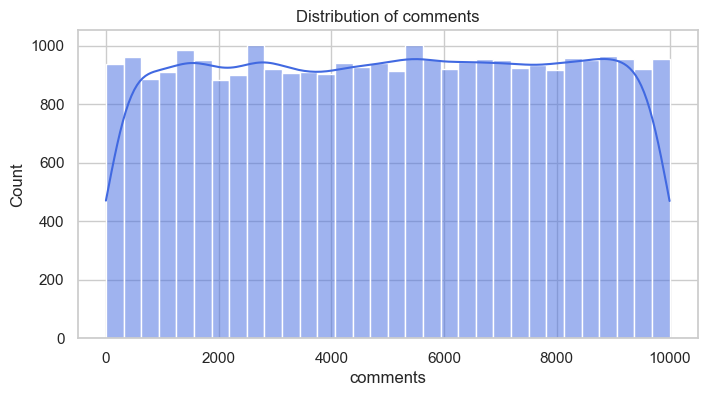

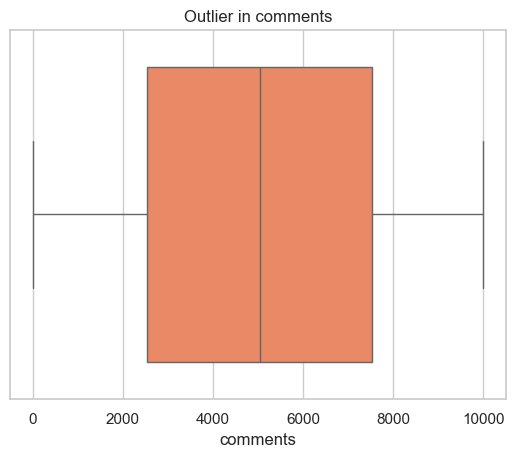

<Figure size 640x480 with 0 Axes>

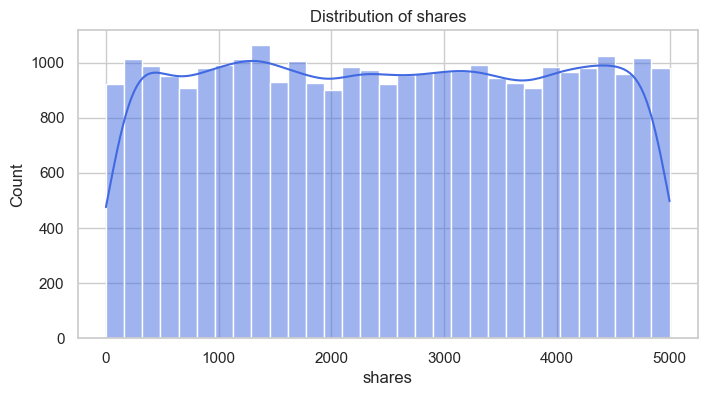

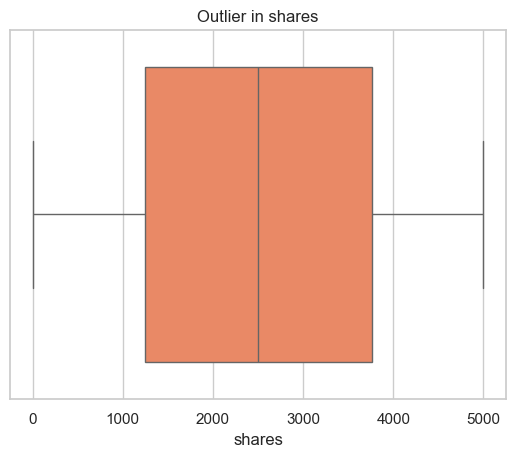

<Figure size 640x480 with 0 Axes>

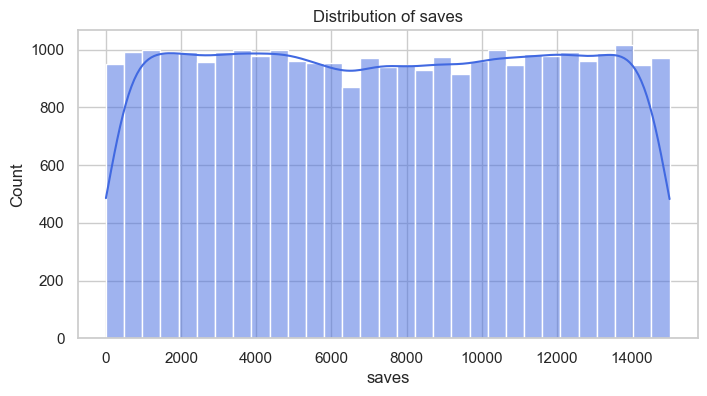

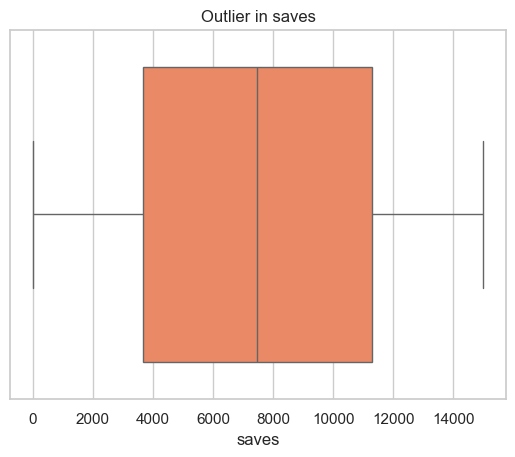

<Figure size 640x480 with 0 Axes>

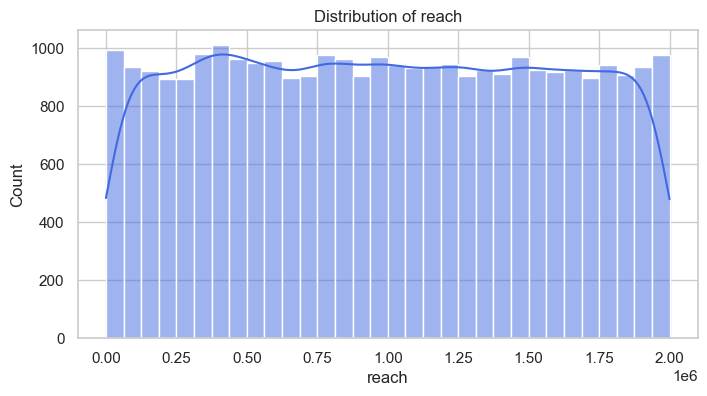

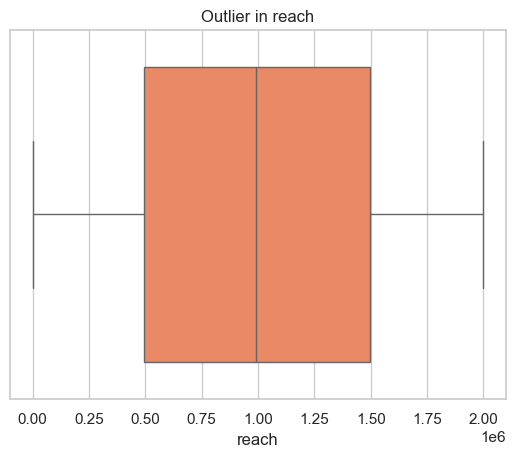

<Figure size 640x480 with 0 Axes>

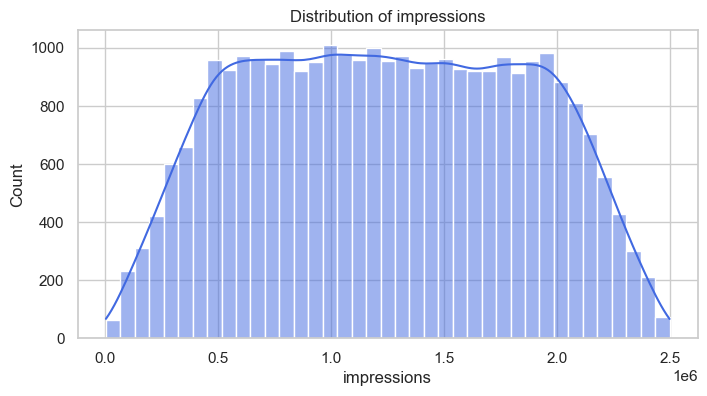

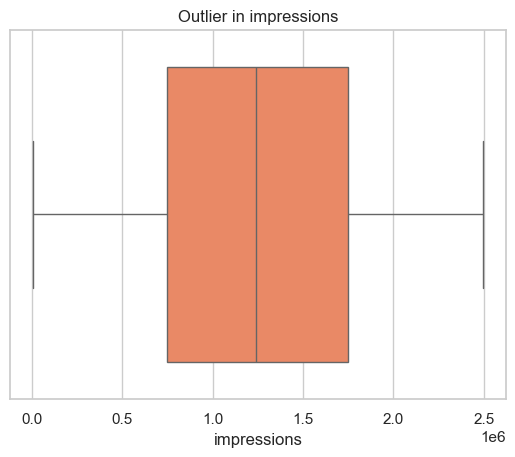

<Figure size 640x480 with 0 Axes>

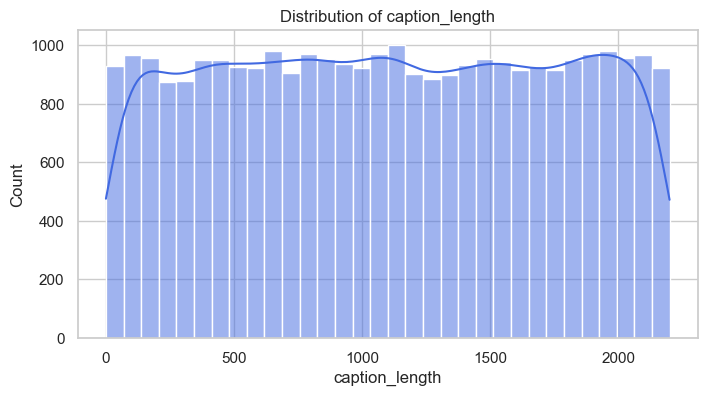

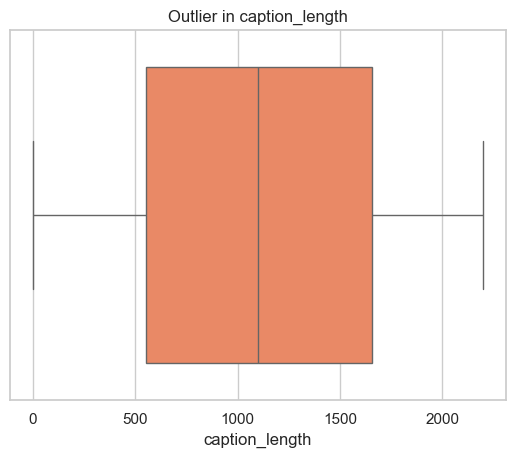

<Figure size 640x480 with 0 Axes>

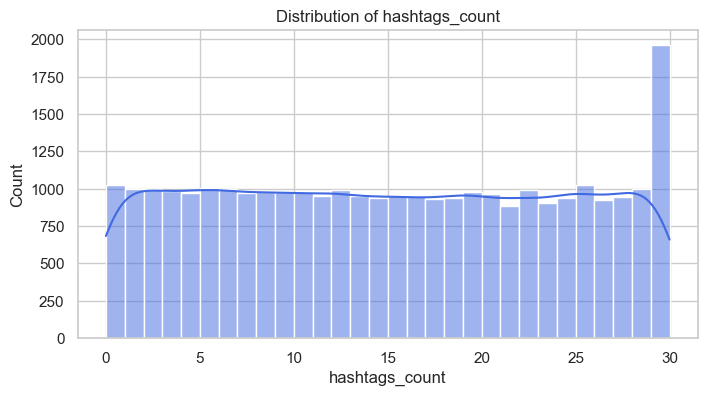

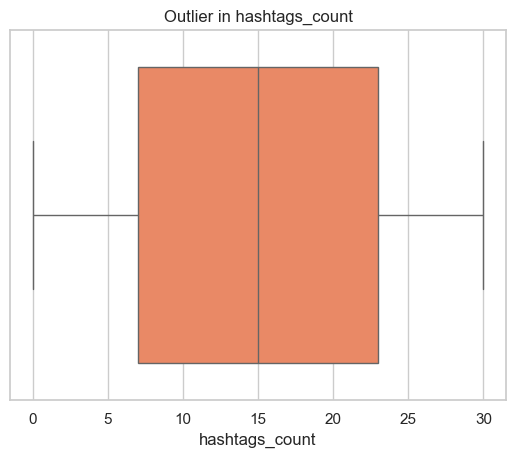

<Figure size 640x480 with 0 Axes>

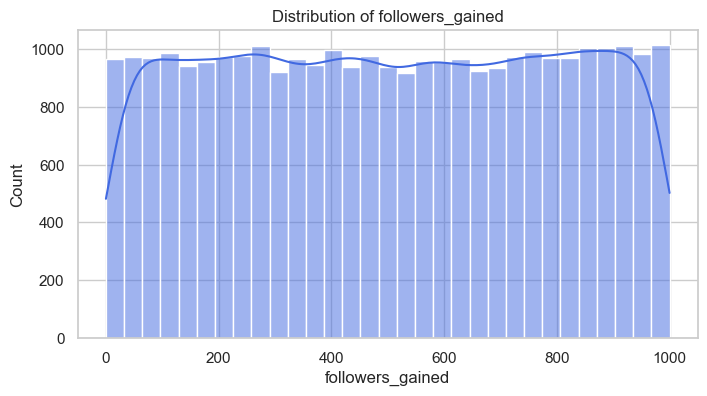

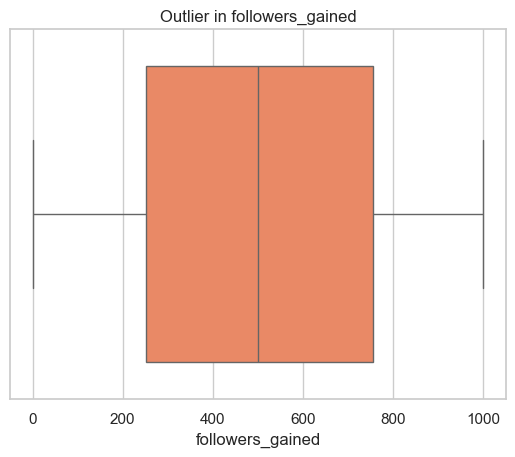

<Figure size 640x480 with 0 Axes>

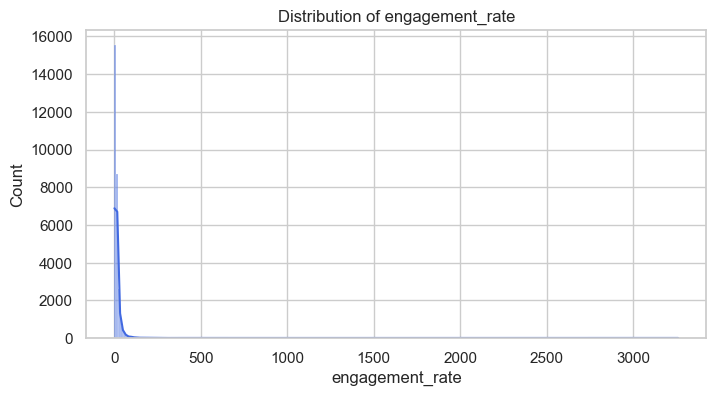

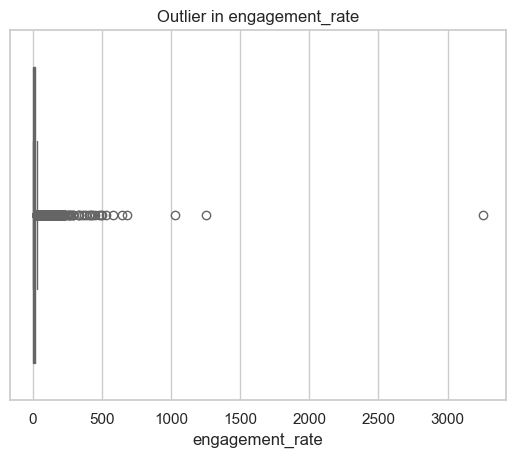

<Figure size 640x480 with 0 Axes>

In [12]:
#Univariate Analysis
#Focus: understand individual feature behavior (distribution, skew, outliers).
num_cols = ['likes','comments','shares','saves','reach','impressions',
            'caption_length','hashtags_count','followers_gained','engagement_rate']
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(insta_df[col],kde=True, color='royalblue')
    plt.title(f"Distribution of {col}")
    plt.show()

    sns.boxplot(x=insta_df[col], color='coral')
    plt.title(f"Outlier in {col}")
    plt.show()
    plt.savefig(f"Distribution of {col}")

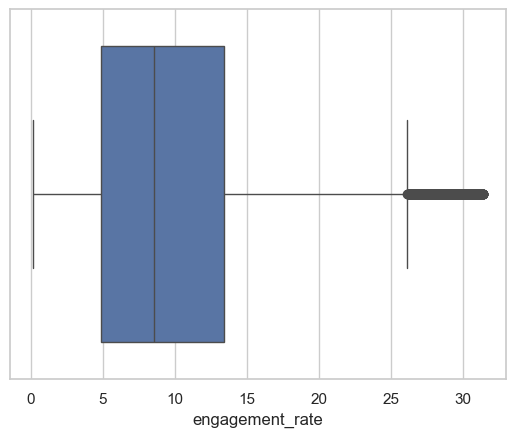

In [13]:
q1 = insta_df['engagement_rate'].quantile(0.25)
q3 = insta_df['engagement_rate'].quantile(0.75)
iqr = q3 - q1 
upper = q3 + 1.5 * iqr
clean_engagement_rate = insta_df[insta_df['engagement_rate']<=upper]

sns.boxplot(x=clean_engagement_rate['engagement_rate'])
plt.show()

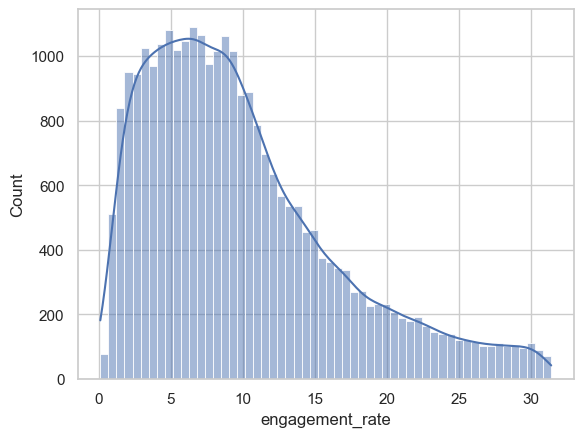

<Figure size 640x480 with 0 Axes>

In [14]:
sns.histplot(clean_engagement_rate['engagement_rate'], kde=True)
plt.show()
plt.savefig("engagement_rate")

In [15]:
insta_df['clean_engagement_rate'] = insta_df['engagement_rate'].clip(upper=upper)

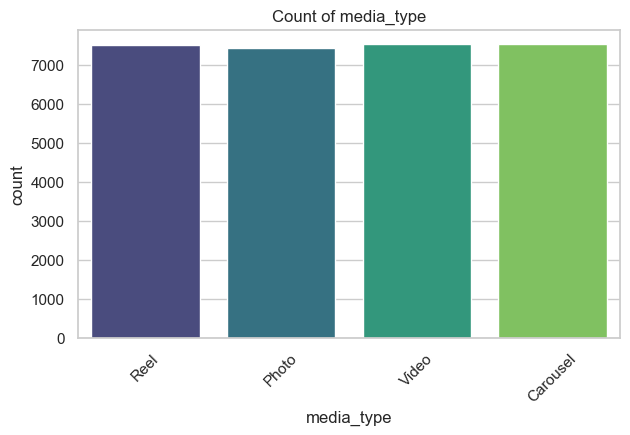

<Figure size 640x480 with 0 Axes>

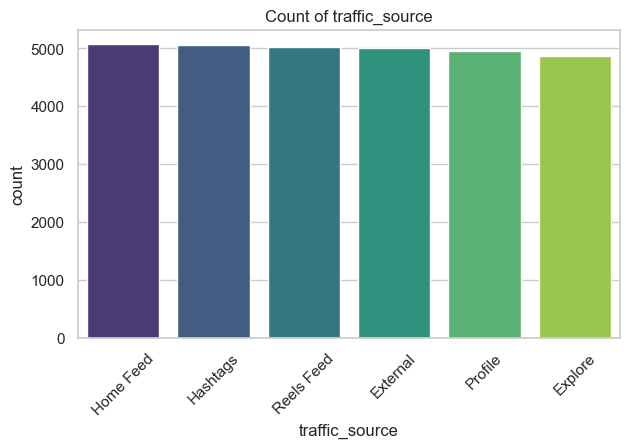

<Figure size 640x480 with 0 Axes>

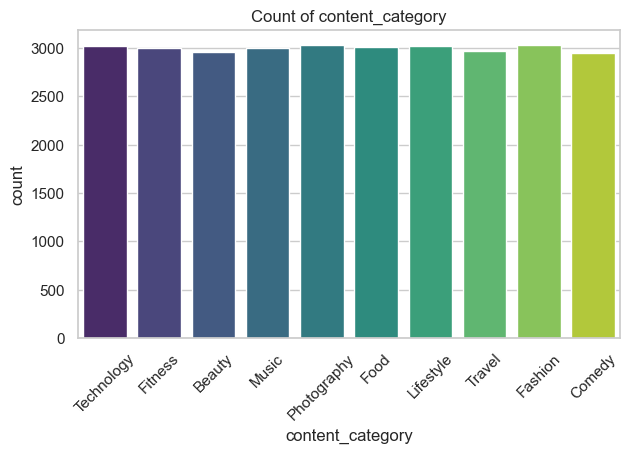

<Figure size 640x480 with 0 Axes>

In [16]:
cat_cols = ['media_type','traffic_source','content_category']

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=insta_df[col], palette='viridis')
    plt.title(f"Count of {col}")
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()
    plt.savefig(f"Count of {col}")
    

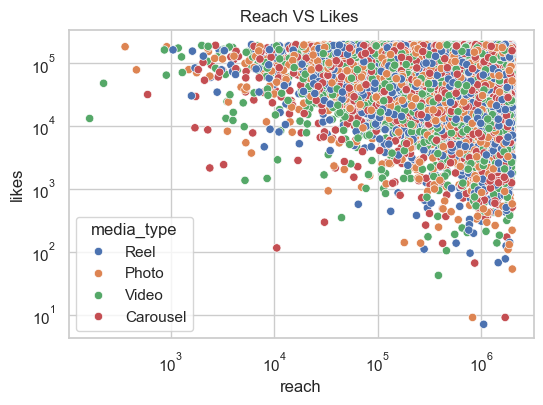

In [17]:
#Bivariate Analysis

#Now we study relationships between pairs of features.

#Continuous vs continuous (scatter)
plt.figure(figsize=(6,4))
sns.scatterplot(x=insta_df['reach'],y=insta_df['likes'], hue=insta_df['media_type'])
plt.xscale('log'); plt.yscale('log')
plt.title("Reach VS Likes ")
plt.show()

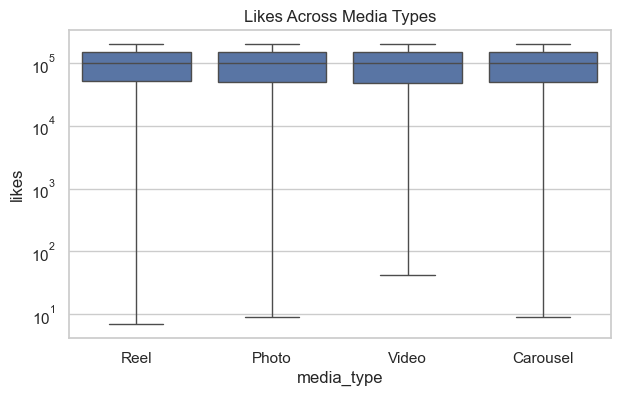

In [18]:
#likes by media_type
plt.figure(figsize=(7,4))
sns.boxplot(x='media_type', y='likes', data=insta_df)
plt.yscale('log')
plt.title('Likes Across Media Types')
plt.show()

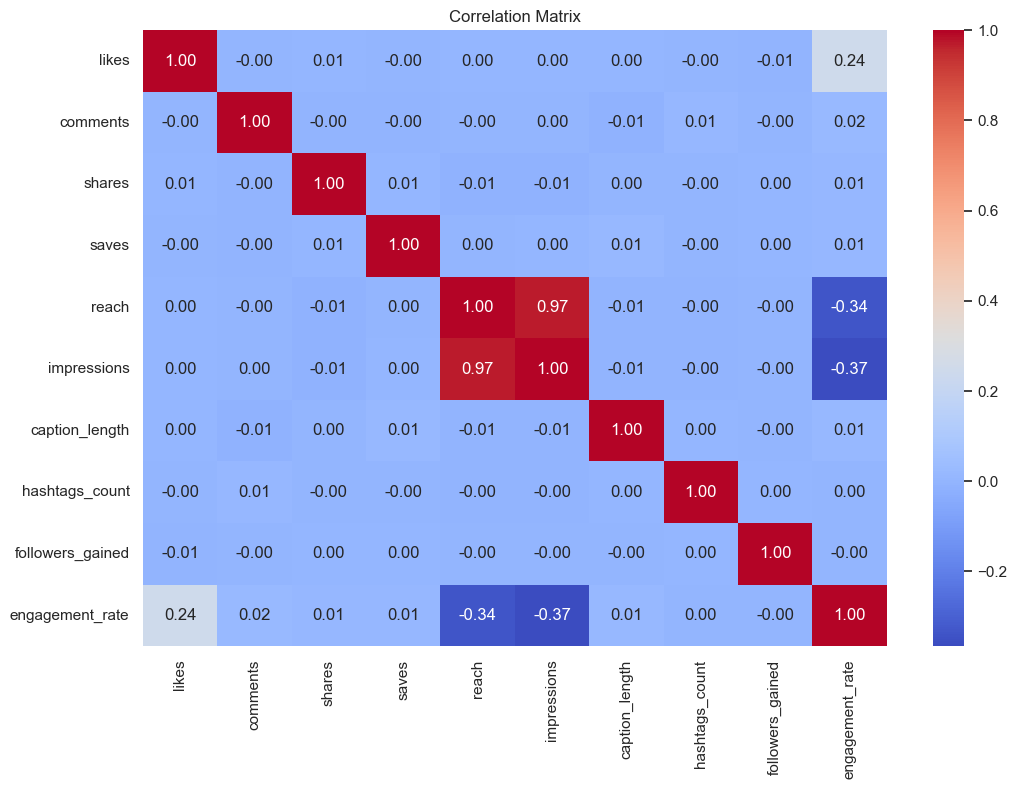

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(insta_df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()
plt.savefig("Correlation Matrix")


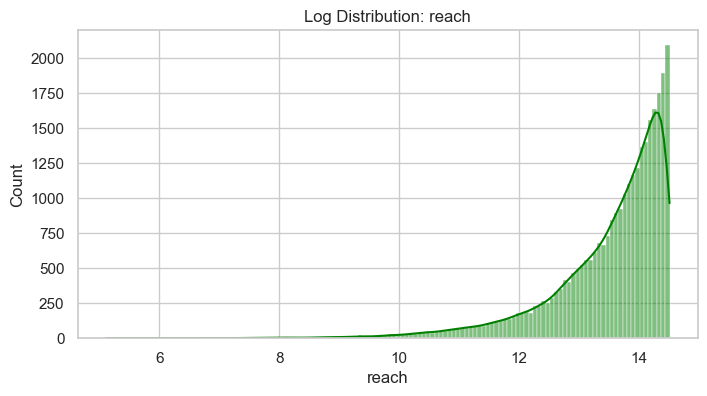

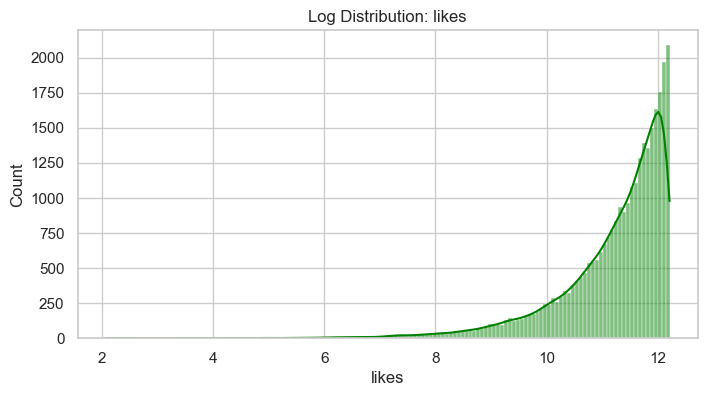

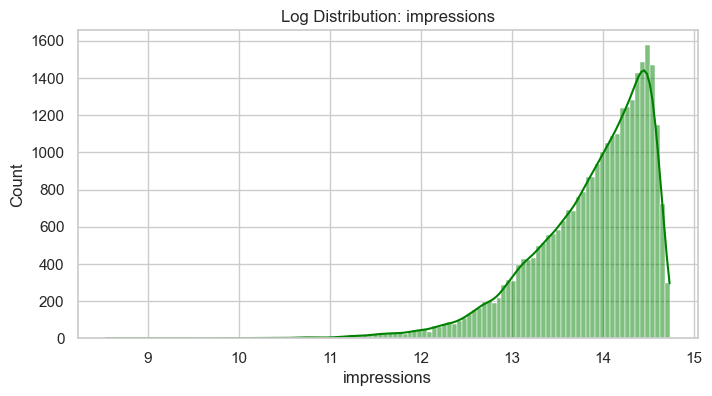

In [20]:
#Distribution Analysis (Deep Dive)
for col in ['reach','likes','impressions']:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(insta_df[col]), kde=True, color='green')
    plt.title(f"Log Distribution: {col}")
    plt.show()


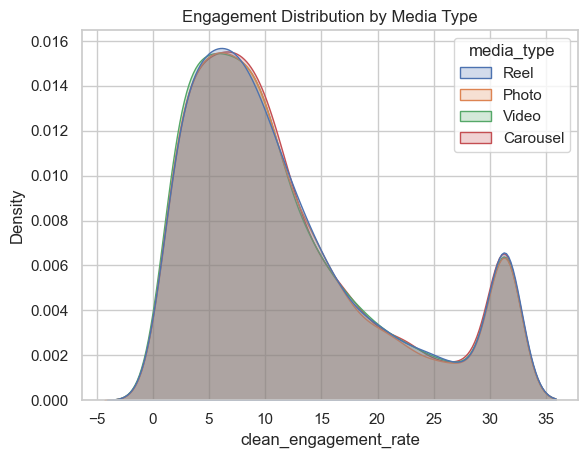

In [21]:
#KDE comparison: Reels vs Photos, 
sns.kdeplot(data=insta_df, x='clean_engagement_rate', hue='media_type', fill=True)
plt.title("Engagement Distribution by Media Type")
plt.show()


In [22]:
from scipy.stats import zscore
columns_to_check = ['likes', 'comments', 'shares', 'saves', 'reach', 'impressions','caption_length', 'hashtags_count', 'followers_gained', 'clean_engagement_rate']
df_z = insta_df[columns_to_check].apply(zscore)
outliers = (df_z.abs() > 3).sum()
outliers

likes                    0
comments                 0
shares                   0
saves                    0
reach                    0
impressions              0
caption_length           0
hashtags_count           0
followers_gained         0
clean_engagement_rate    0
dtype: int64

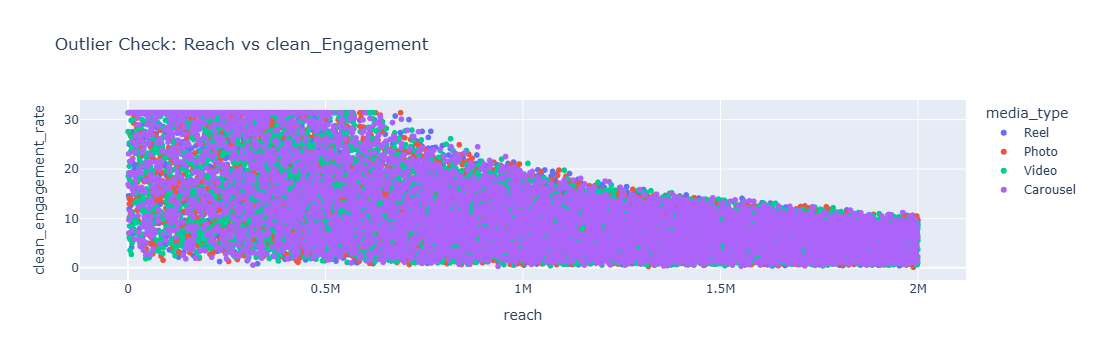

In [23]:
px.scatter(insta_df, x="reach", y="clean_engagement_rate", color="media_type",
           title="Outlier Check: Reach vs clean_Engagement")


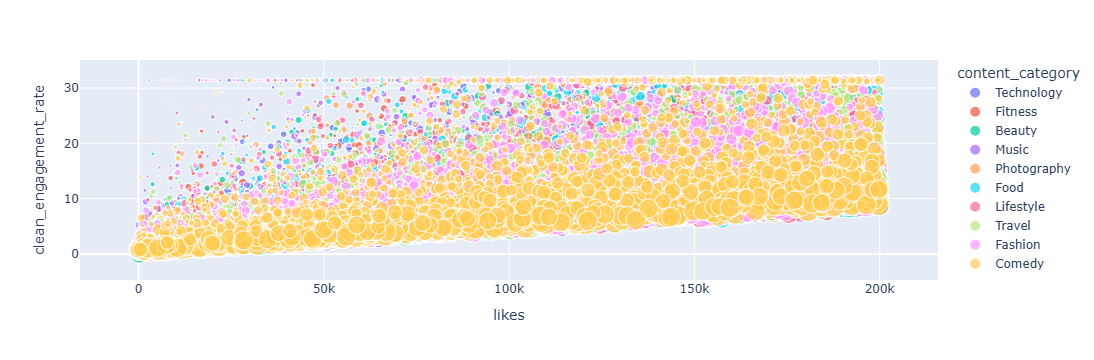

In [24]:
px.scatter(insta_df, x='likes', y='clean_engagement_rate', color='content_category',
           size='reach', hover_data=['media_type'])


In [25]:
#Engagement raw
insta_df['engagement_raw'] = (insta_df['likes'] + insta_df['comments'] + insta_df['shares'] + insta_df['saves'])

In [26]:
#Engagement per reach
insta_df['engagement_per_reach'] = insta_df['engagement_raw'] / (insta_df['reach'] + 1)

In [27]:
#Impressions-to-reach ratio
insta_df['impressions_reach_ratio'] = insta_df['impressions'] / (insta_df['reach'] + 1)

In [28]:
#Likes per reach
insta_df['likes_per_reach'] = insta_df['likes'] / (insta_df['reach'] + 1)

In [29]:
#Hashtags effectiveness
insta_df['hashtags_density'] = insta_df['hashtags_count'] / (insta_df['caption_length'] + 1)

In [30]:
insta_df['likes_comments_ratio'] = insta_df['likes'] / (insta_df['comments'] + 1)
insta_df['save_rate'] = insta_df['saves'] / (insta_df['reach'] + 1)
insta_df['share_rate'] = insta_df['shares'] / (insta_df['reach'] + 1)


In [31]:
insta_df

,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,...,content_category,clean_engagement_rate,engagement_raw,engagement_per_reach,impressions_reach_ratio,likes_per_reach,hashtags_density,likes_comments_ratio,save_rate,share_rate
0,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,...,Technology,4.97,50109,0.081473,1.638519,0.051423,0.002237,4.183466,0.010394,0.007365
1,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,...,Fitness,5.59,75185,0.060777,1.087972,0.051093,0.014793,18.105414,0.005504,0.001358
2,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,...,Beauty,8.29,108228,0.095992,1.157785,0.083703,0.098765,25.314646,0.007421,0.001562
3,Reel,172053,7222,2875,9290,764030,897874,446,11,402,...,Music,21.32,191440,0.250566,1.175180,0.225191,0.024609,23.820158,0.012159,0.003763
4,Video,99646,2703,4444,9746,7004,495406,1905,8,155,...,Technology,23.52,116539,16.636545,70.721770,14.224982,0.004197,36.851331,1.391292,0.634404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,Video,46046,8354,3847,11095,597992,820688,1254,18,124,...,Travel,8.45,69342,0.115958,1.372404,0.077001,0.014343,5.511191,0.018554,0.006433
29995,Carousel,67711,3266,458,12380,1908094,2218288,1427,4,310,...,Beauty,3.78,83815,0.043926,1.162567,0.035486,0.002801,20.725742,0.006488,0.000240
29996,Photo,52326,7328,3687,7619,1984066,2447893,713,4,223,...,Photography,2.90,70960,0.035765,1.233775,0.026373,0.005602,7.139582,0.003840,0.001858
29997,Carousel,158113,5890,2573,6329,1984709,2001092,1341,22,978,...,Technology,8.64,172905,0.087119,1.008254,0.079666,0.016393,26.839756,0.003189,0.001296


In [32]:
#Prepare Data
target = 'clean_engagement_rate'

X = insta_df.drop(columns=[target])
y = insta_df[target]


In [33]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [34]:
#Identify categorical features
cat_features = [X.columns.get_loc(col) for col in X.columns if X[col].dtype == 'object']

In [35]:
# CatBoost Regressor
model = CatBoostRegressor(depth=8,learning_rate=0.05,iterations=1200,loss_function='RMSE',eval_metric='RMSE',random_seed=42,verbose=200)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))


0:	learn: 8.3440712	test: 8.4967062	best: 8.4967062 (0)	total: 230ms	remaining: 4m 35s
200:	learn: 0.1149845	test: 0.1298775	best: 0.1298775 (200)	total: 14s	remaining: 1m 9s
400:	learn: 0.0826199	test: 0.1010506	best: 0.1010506 (400)	total: 27.9s	remaining: 55.6s
600:	learn: 0.0700524	test: 0.0923973	best: 0.0923973 (600)	total: 41.6s	remaining: 41.5s
800:	learn: 0.0627965	test: 0.0883834	best: 0.0883834 (800)	total: 54.9s	remaining: 27.4s
1000:	learn: 0.0573185	test: 0.0857686	best: 0.0857686 (1000)	total: 1m 8s	remaining: 13.6s
1199:	learn: 0.0529143	test: 0.0841651	best: 0.0841490 (1198)	total: 1m 22s	remaining: 0us

bestTest = 0.08414897088
bestIteration = 1198

Shrink model to first 1199 iterations.


In [36]:
#Evaluate
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 0.08414896388776469
MAE: 0.04820217763806324
R2 Score: 0.999911069469457


In [37]:
# This is where CatBoost shines
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,engagement_rate,85.868689
1,likes_per_reach,5.139962
2,engagement_per_reach,4.749931
3,likes,1.463040
4,engagement_raw,1.038699
5,impressions,0.512399
6,impressions_reach_ratio,0.438790
7,reach,0.412291
8,share_rate,0.124504
9,likes_comments_ratio,0.070522
